# AI-Enabled Visa Status Prediction & Processing Time Estimator
## Module 2 — Exploratory Data Analysis & Feature Engineering

This notebook performs in-depth EDA on the cleaned U.S. visa application dataset and engineers new features for downstream predictive modelling.

## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
sns.set_style('darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

DATA_PATH = '/content/cleaned_us_visa_dataset.csv'

df = pd.read_csv(DATA_PATH)
df['case_received_date'] = pd.to_datetime(df['case_received_date'], errors='coerce')
df['decision_date']      = pd.to_datetime(df['decision_date'],      errors='coerce')

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head(3)

Dataset shape : (14622, 14)
Columns       : ['country_of_citizenship', 'class_of_admission', 'employer_state', 'us_economic_sector', 'case_status', 'foreign_worker_info_education', 'foreign_worker_info_major', 'case_received_date', 'decision_date', 'processing_days', 'application_year', 'application_month', 'application_quarter', 'application_dayofweek']


,country_of_citizenship,class_of_admission,employer_state,us_economic_sector,case_status,foreign_worker_info_education,foreign_worker_info_major,case_received_date,decision_date,processing_days,application_year,application_month,application_quarter,application_dayofweek
0,INDIA,H-1B,WISCONSIN,UNKNOWN,CERTIFIED,BACHELOR'S,MECHANICAL ENGINEERING,2013-11-19,2015-05-29,556,2013,11,4,1
1,SOUTH KOREA,UNKNOWN,MISSISSIPPI,UNKNOWN,DENIED,UNKNOWN,UNKNOWN,2013-11-12,2015-06-26,591,2013,11,4,1
2,GERMANY,H-1B,COLORADO,UNKNOWN,DENIED,DOCTORATE,MOLECULAR BIOLOGY,2013-11-27,2014-10-16,323,2013,11,4,2


In [4]:
print('DATA TYPES')
df.info()
print('DESCRIPTIVE STATISTICS (numeric)')
df.describe().T

DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14622 entries, 0 to 14621
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   country_of_citizenship         14622 non-null  object        
 1   class_of_admission             14622 non-null  object        
 2   employer_state                 14622 non-null  object        
 3   us_economic_sector             14622 non-null  object        
 4   case_status                    14622 non-null  object        
 5   foreign_worker_info_education  14622 non-null  object        
 6   foreign_worker_info_major      14622 non-null  object        
 7   case_received_date             14622 non-null  datetime64[ns]
 8   decision_date                  14622 non-null  datetime64[ns]
 9   processing_days                14622 non-null  int64         
 10  application_year               14622 non-null  int64         
 11  appl

,count,mean,min,25%,50%,75%,max,std
case_received_date,14622,2014-02-25 23:54:05.465736192,2010-10-29 00:00:00,2013-11-08 00:00:00,2014-03-10 00:00:00,2014-06-30 00:00:00,2015-03-26 00:00:00,NaN
decision_date,14622,2015-06-11 06:12:15.658596864,2014-10-01 00:00:00,2015-05-01 00:00:00,2015-06-17 00:00:00,2015-08-06 00:00:00,2015-09-30 00:00:00,NaN
processing_days,14622.0,470.262618,136.0,428.0,490.0,555.0,1446.0,199.688186
application_year,14622.0,2013.606415,2010.0,2013.0,2014.0,2014.0,2015.0,0.642089
application_month,14622.0,7.084325,1.0,4.0,7.0,11.0,12.0,3.66099
application_quarter,14622.0,2.67501,1.0,2.0,3.0,4.0,4.0,1.171197
application_dayofweek,14622.0,2.131856,0.0,1.0,2.0,3.0,6.0,1.560441


In [5]:
neg_or_zero = (df['processing_days'] <= 0).sum()
print(f'Rows with processing_days ≤ 0 : {neg_or_zero}')
print(f'Min  : {df["processing_days"].min()}')
print(f'Max  : {df["processing_days"].max()}')
print(f'Mean : {df["processing_days"].mean():.1f} days')
print(f'Median: {df["processing_days"].median():.1f} days')
df.rename(columns={
    'application_month'   : 'month',
    'application_quarter' : 'quarter',
    'application_dayofweek': 'dayofweek'
}, inplace=True, errors='ignore')

Rows with processing_days ≤ 0 : 0
Min  : 136
Max  : 1446
Mean : 470.3 days
Median: 490.0 days


## 2. Distribution of Processing Times

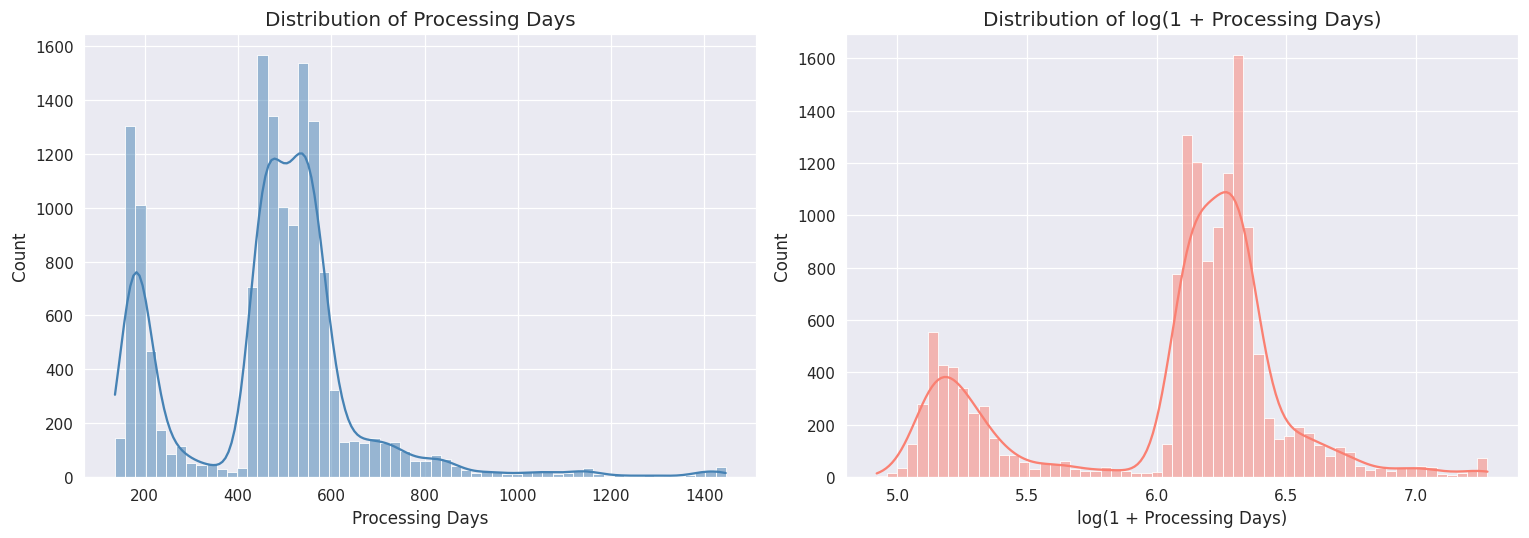

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
sns.histplot(df['processing_days'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Processing Days')
axes[0].set_xlabel('Processing Days')
axes[0].set_ylabel('Count')

# Log-scaled version (useful for skewed distributions)
sns.histplot(np.log1p(df['processing_days']), bins=60, kde=True,
             ax=axes[1], color='salmon')
axes[1].set_title('Distribution of log(1 + Processing Days)')
axes[1].set_xlabel('log(1 + Processing Days)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

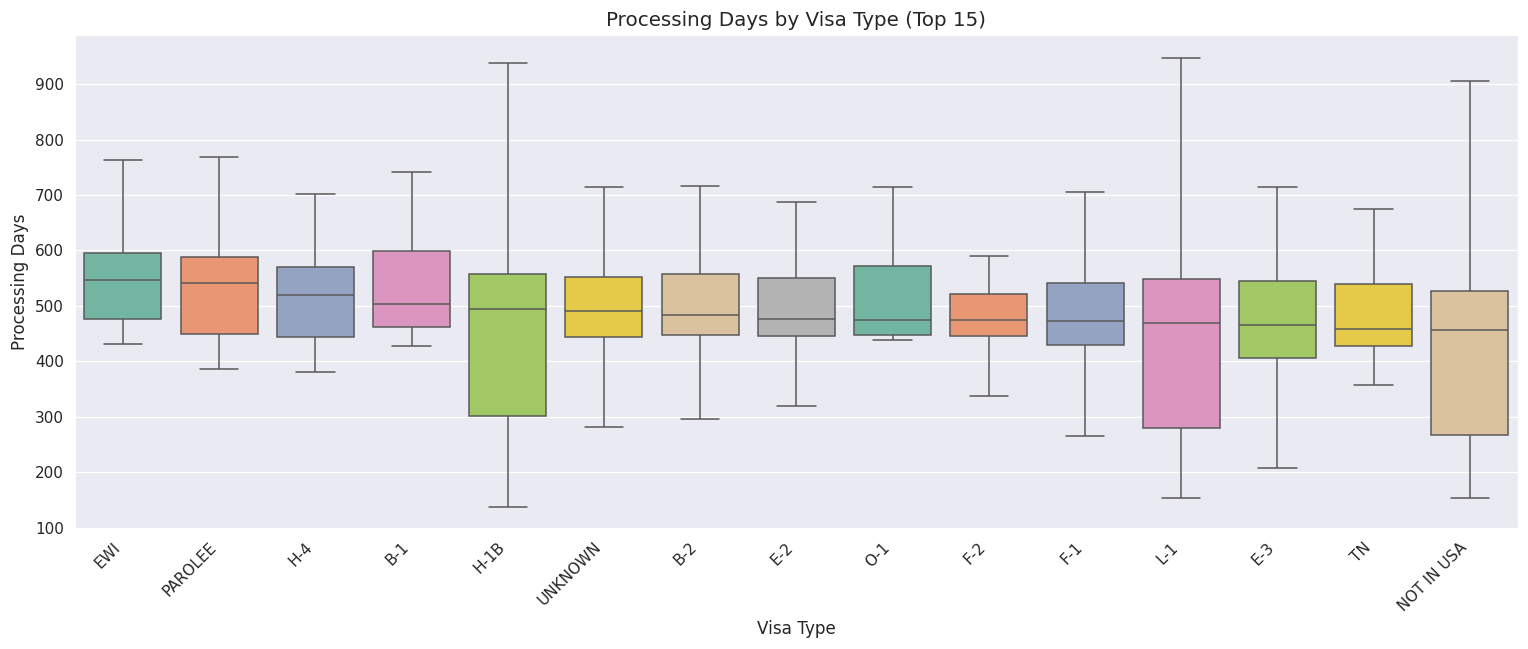

In [7]:
# ── Boxplot by class_of_admission (top 15 visa types) ─────────────────────────
top15_visa = df['class_of_admission'].value_counts().nlargest(15).index
visa_df    = df[df['class_of_admission'].isin(top15_visa)]

plt.figure(figsize=(14, 6))
order = (visa_df.groupby('class_of_admission')['processing_days']
                .median().sort_values(ascending=False).index)
sns.boxplot(data=visa_df, x='class_of_admission', y='processing_days',
            order=order, palette='Set2', showfliers=False)
plt.title('Processing Days by Visa Type (Top 15)')
plt.xlabel('Visa Type')
plt.ylabel('Processing Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

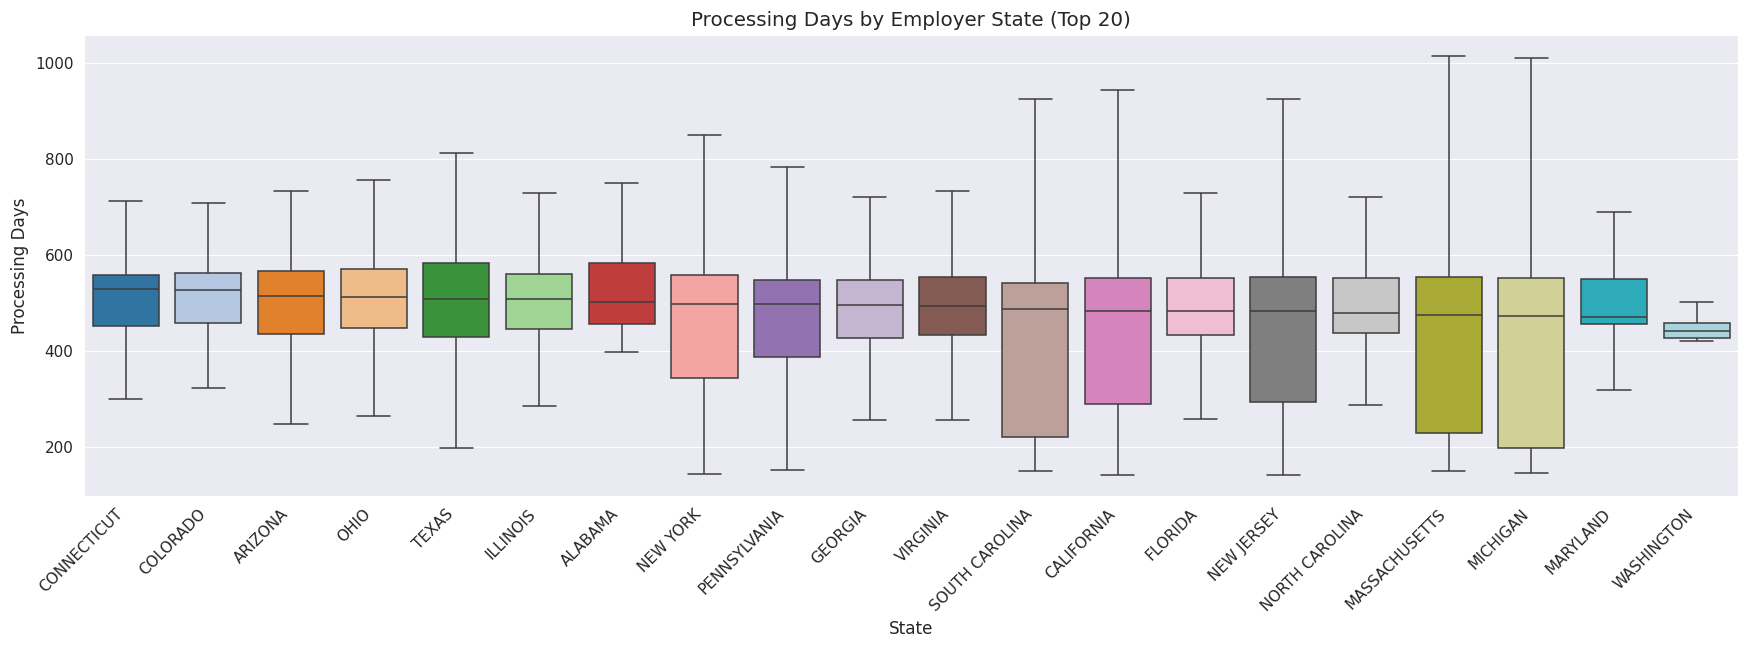

In [8]:
# ── Boxplot by employer_state (top 20 states by frequency) ───────────────────
top20_states = df['employer_state'].value_counts().nlargest(20).index
state_df     = df[df['employer_state'].isin(top20_states)]

plt.figure(figsize=(16, 6))
order_s = (state_df.groupby('employer_state')['processing_days']
                   .median().sort_values(ascending=False).index)
sns.boxplot(data=state_df, x='employer_state', y='processing_days',
            order=order_s, palette='tab20', showfliers=False)
plt.title('Processing Days by Employer State (Top 20)')
plt.xlabel('State')
plt.ylabel('Processing Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

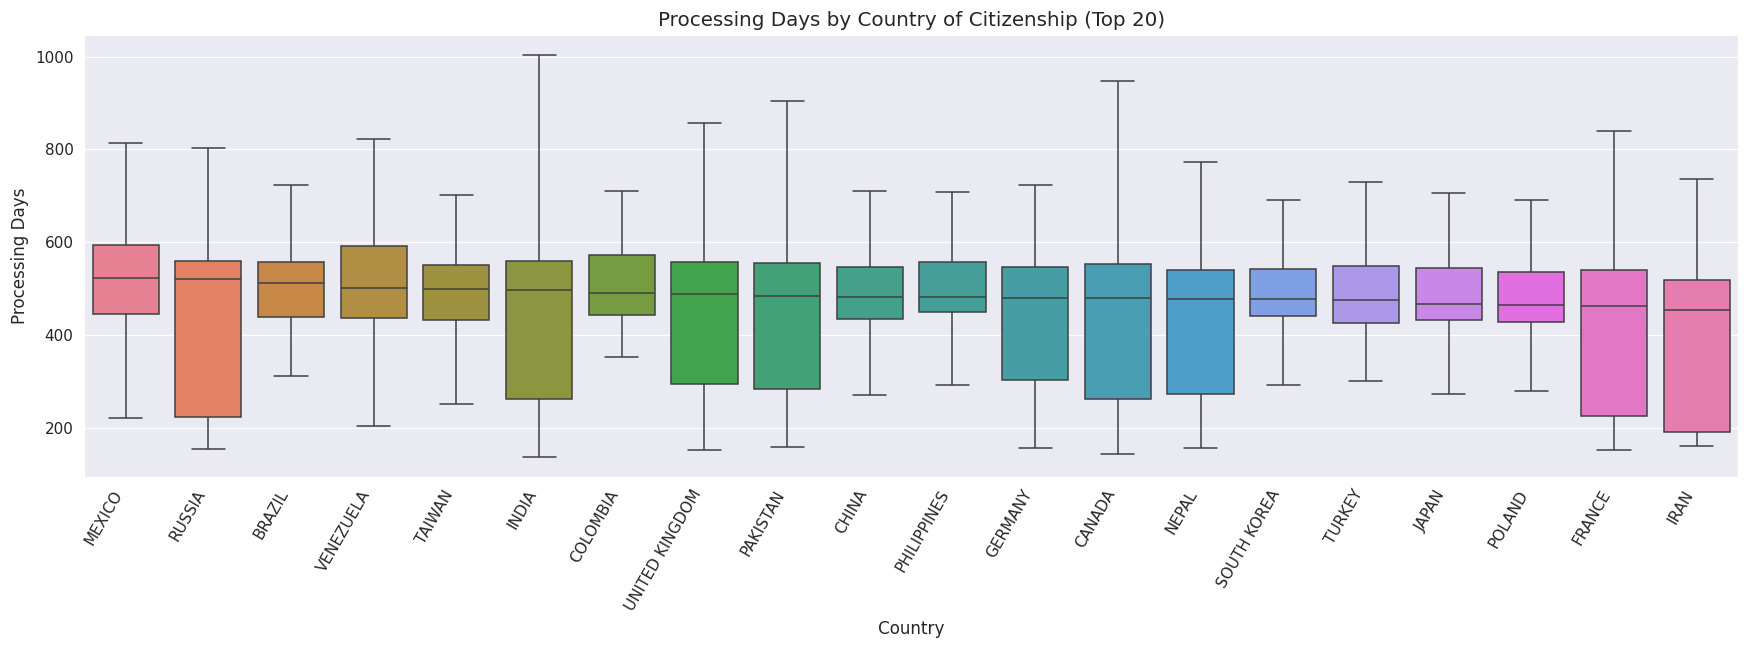

In [9]:
# ── Boxplot by country_of_citizenship (top 20 countries) ─────────────────────
top20_countries = df['country_of_citizenship'].value_counts().nlargest(20).index
country_df      = df[df['country_of_citizenship'].isin(top20_countries)]

plt.figure(figsize=(16, 6))
order_c = (country_df.groupby('country_of_citizenship')['processing_days']
                     .median().sort_values(ascending=False).index)
sns.boxplot(data=country_df, x='country_of_citizenship', y='processing_days',
            order=order_c, palette='husl', showfliers=False)
plt.title('Processing Days by Country of Citizenship (Top 20)')
plt.xlabel('Country')
plt.ylabel('Processing Days')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

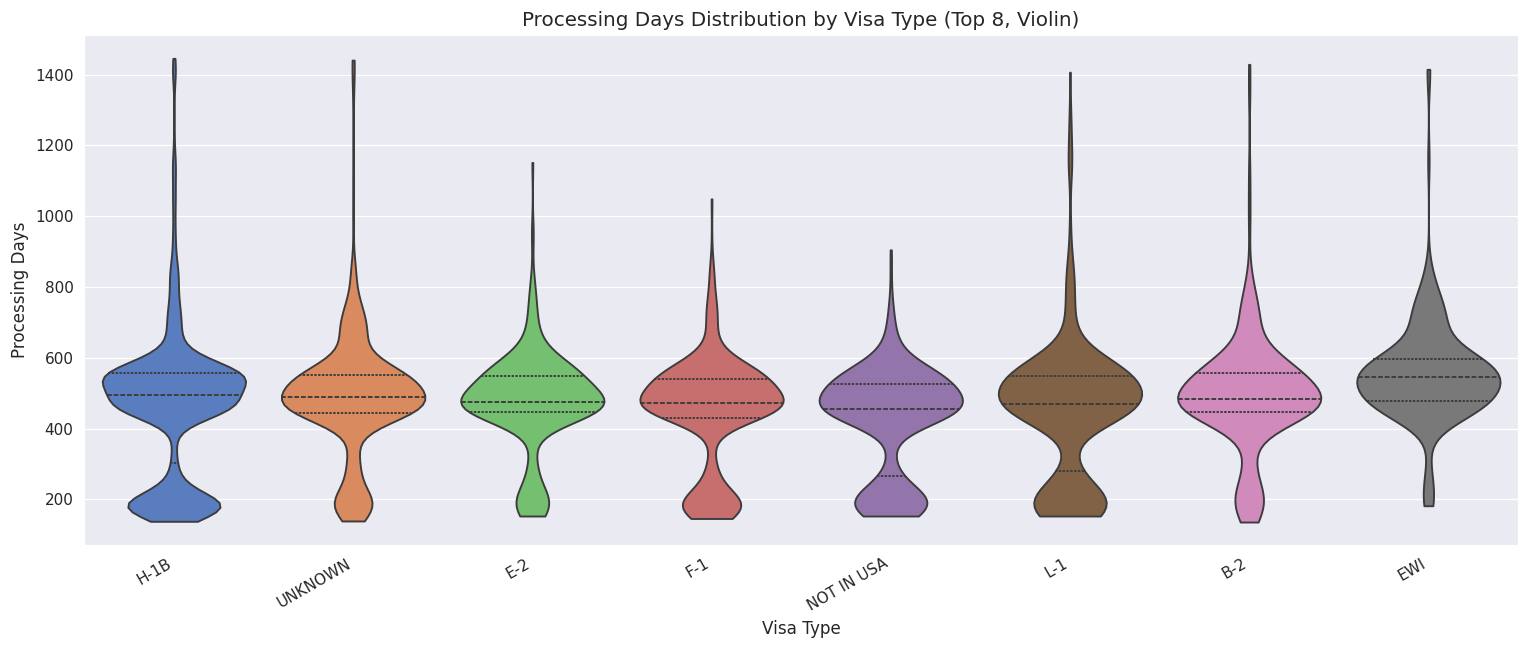

In [10]:
# ── Violin plots for top 8 visa types ────────────────────────────────────────
top8_visa  = df['class_of_admission'].value_counts().nlargest(8).index
violin_df  = df[df['class_of_admission'].isin(top8_visa)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=violin_df, x='class_of_admission', y='processing_days',
               palette='muted', inner='quartile', cut=0)
plt.title('Processing Days Distribution by Visa Type (Top 8, Violin)')
plt.xlabel('Visa Type')
plt.ylabel('Processing Days')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Temporal Trends

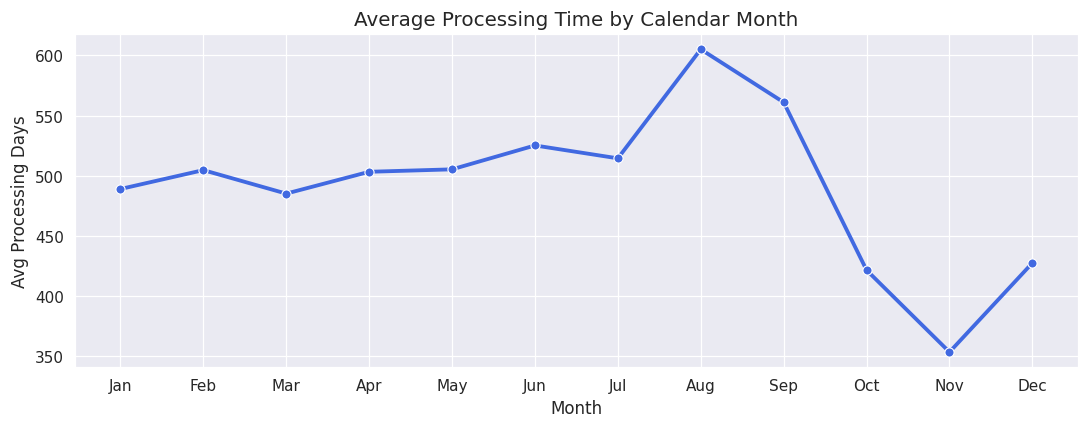

In [11]:
# ── Average processing time per calendar month (across all years) ─────────────
monthly_avg = (df.groupby('month')['processing_days']
                 .mean().reset_index()
                 .rename(columns={'processing_days': 'avg_processing'}))

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_avg, x='month', y='avg_processing',
             marker='o', linewidth=2.5, color='royalblue')
plt.title('Average Processing Time by Calendar Month')
plt.xlabel('Month')
plt.ylabel('Avg Processing Days')
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

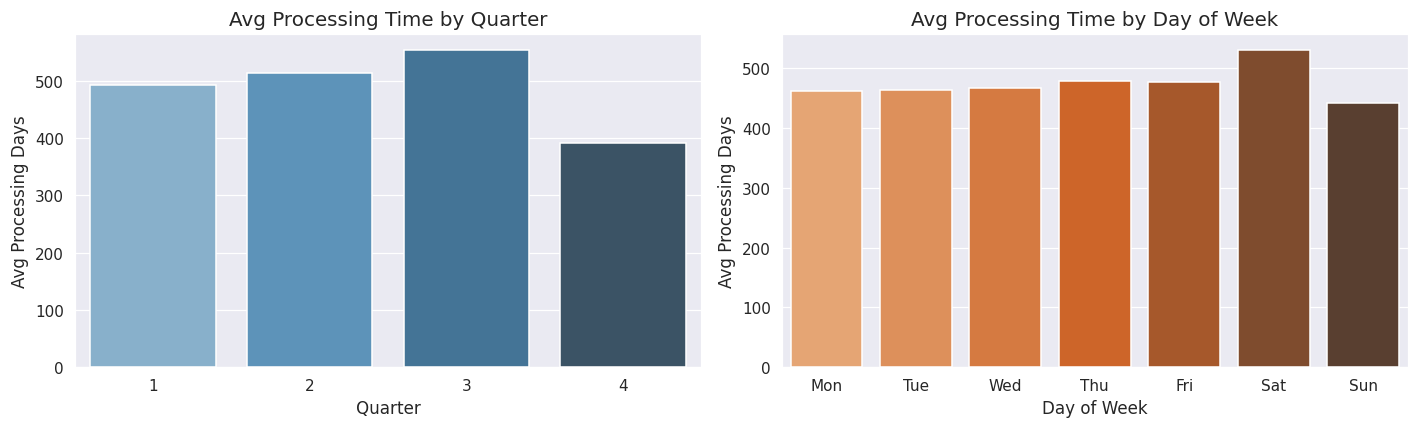

In [12]:
# ── Average processing time per quarter ───────────────────────────────────────
quarter_avg = (df.groupby('quarter')['processing_days']
                 .mean().reset_index()
                 .rename(columns={'processing_days': 'avg_processing'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=quarter_avg, x='quarter', y='avg_processing',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Avg Processing Time by Quarter')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Avg Processing Days')

# ── Average processing time per day of week ───────────────────────────────────
dow_avg = (df.groupby('dayofweek')['processing_days']
             .mean().reset_index()
             .rename(columns={'processing_days': 'avg_processing'}))
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg['day_name'] = dow_avg['dayofweek'].apply(lambda x: day_labels[x] if x < 7 else str(x))

sns.barplot(data=dow_avg, x='day_name', y='avg_processing',
            palette='Oranges_d', ax=axes[1])
axes[1].set_title('Avg Processing Time by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Processing Days')

plt.tight_layout()
plt.show()

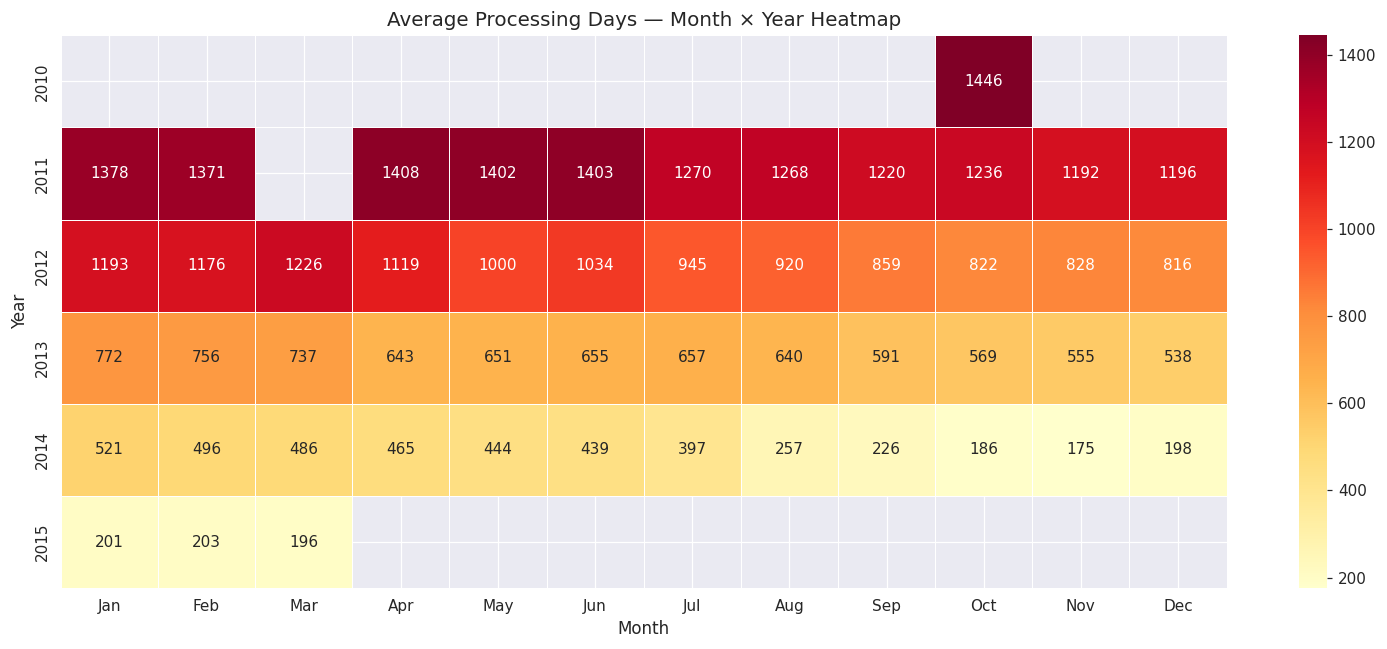

In [13]:
# ── Heatmap: average processing time over (month × year) ─────────────────────
pivot_month_year = (df.groupby(['application_year', 'month'])['processing_days']
                      .mean()
                      .unstack(level='month'))

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_month_year, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white',
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average Processing Days — Month × Year Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## 4. Workload & Regional Insights

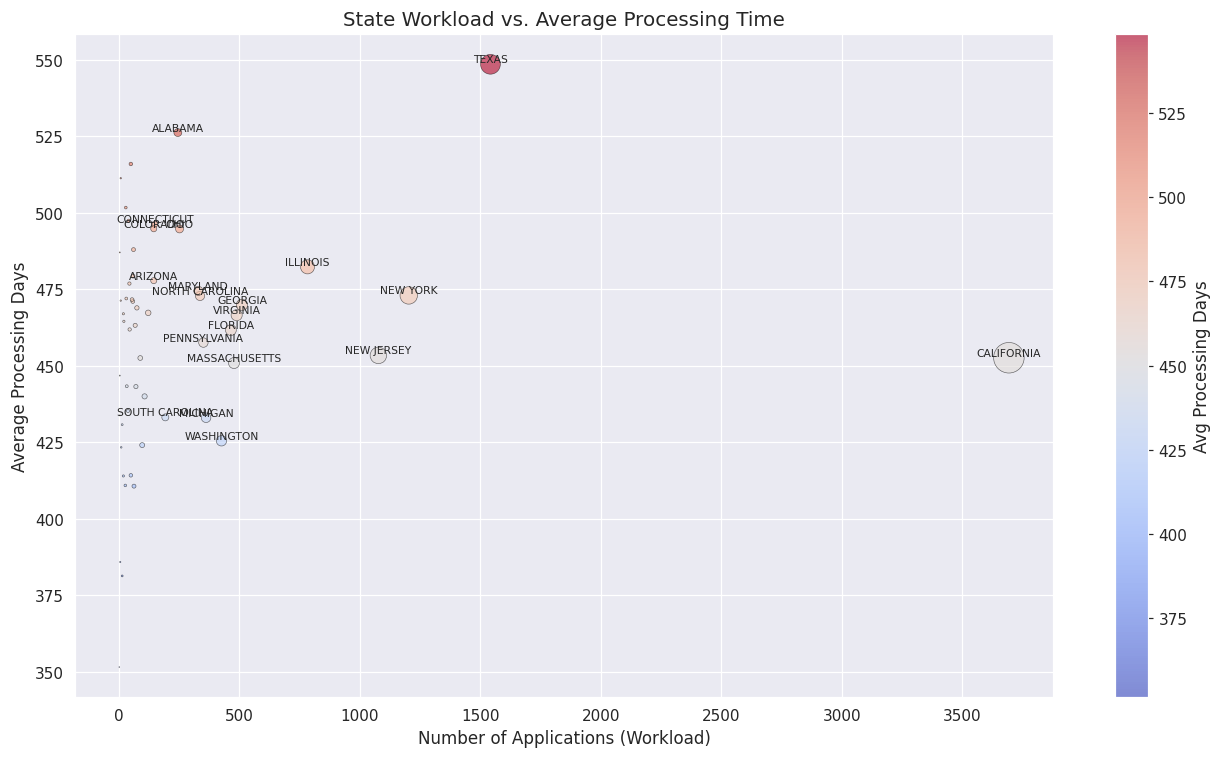

In [14]:
# ── State workload vs. average processing time (scatter) ─────────────────────
state_stats = (df.groupby('employer_state')
                 .agg(count=('processing_days','size'),
                      avg_days=('processing_days','mean'))
                 .reset_index()
                 .sort_values('count', ascending=False))

# Label only top 20 states for readability
top_states_label = state_stats.nlargest(20, 'count')

plt.figure(figsize=(12, 7))
scatter = plt.scatter(state_stats['count'], state_stats['avg_days'],
                      s=state_stats['count']/state_stats['count'].max()*400,
                      alpha=0.6, c=state_stats['avg_days'],
                      cmap='coolwarm', edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, label='Avg Processing Days')
for _, row in top_states_label.iterrows():
    plt.annotate(row['employer_state'],
                 (row['count'], row['avg_days']),
                 fontsize=7, ha='center', va='bottom')
plt.title('State Workload vs. Average Processing Time')
plt.xlabel('Number of Applications (Workload)')
plt.ylabel('Average Processing Days')
plt.tight_layout()
plt.show()

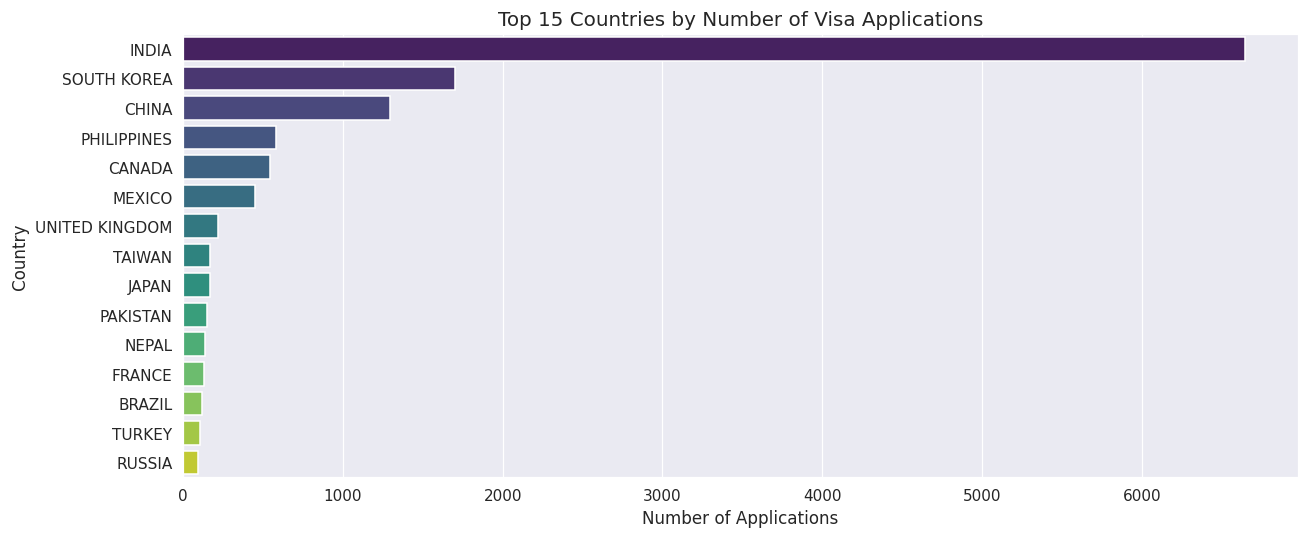

In [15]:
# ── Top 15 countries by application count (bar chart) ────────────────────────
top15_ctry = df['country_of_citizenship'].value_counts().nlargest(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top15_ctry.values, y=top15_ctry.index, palette='viridis')
plt.title('Top 15 Countries by Number of Visa Applications')
plt.xlabel('Number of Applications')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

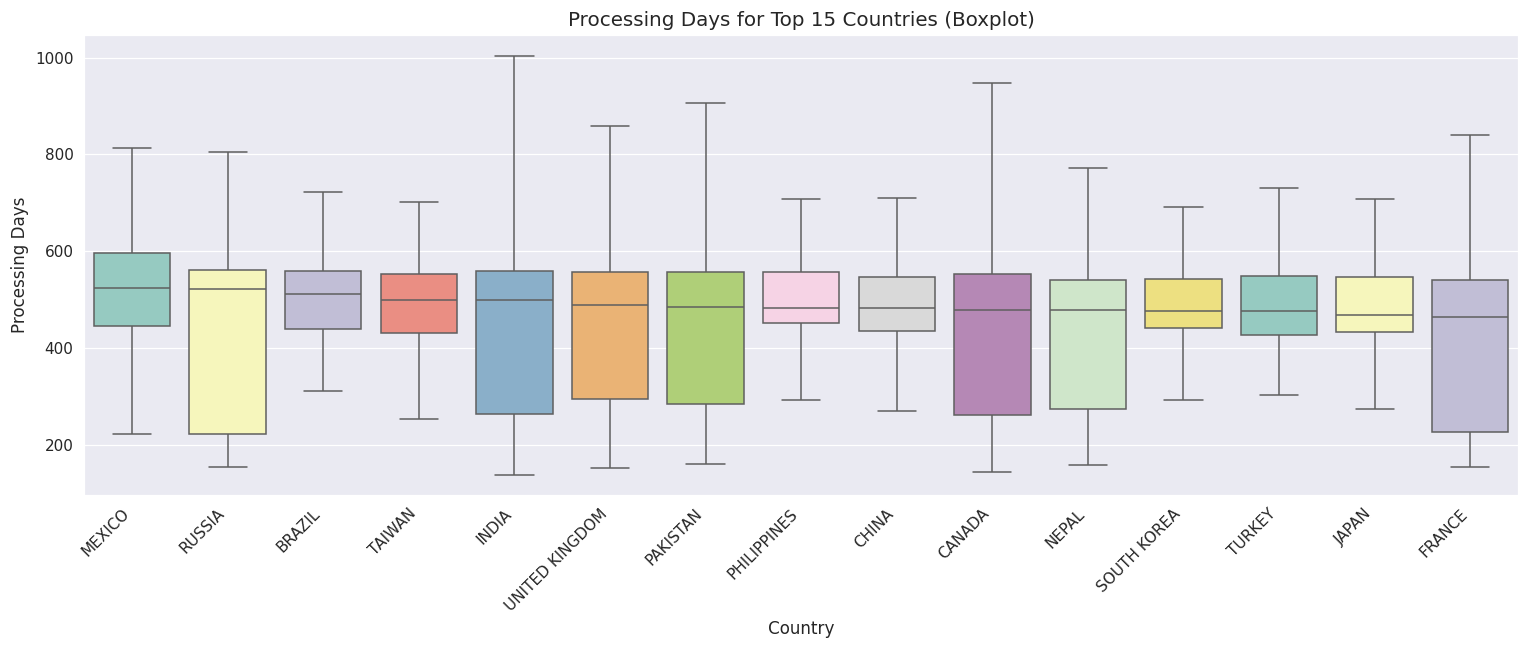

In [16]:
# ── Boxplots for top 15 countries ─────────────────────────────────────────────
top15_country_names = top15_ctry.index.tolist()
df_top15 = df[df['country_of_citizenship'].isin(top15_country_names)]

plt.figure(figsize=(14, 6))
order_top = (df_top15.groupby('country_of_citizenship')['processing_days']
                     .median().sort_values(ascending=False).index)
sns.boxplot(data=df_top15, x='country_of_citizenship', y='processing_days',
            order=order_top, palette='Set3', showfliers=False)
plt.title('Processing Days for Top 15 Countries (Boxplot)')
plt.xlabel('Country')
plt.ylabel('Processing Days')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# ── Choropleth: average processing time by country (Plotly) ──────────────────
country_avg_map = (df.groupby('country_of_citizenship')['processing_days']
                     .mean().reset_index()
                     .rename(columns={'processing_days': 'avg_processing',
                                      'country_of_citizenship': 'country'}))

fig_map = px.choropleth(
    country_avg_map,
    locations='country',
    locationmode='country names',
    color='avg_processing',
    color_continuous_scale='Reds',
    title='Average Visa Processing Days by Country of Citizenship',
    labels={'avg_processing': 'Avg Days'}
)
fig_map.update_layout(height=500, margin=dict(l=0, r=0, t=50, b=0))
fig_map.show()

## 5. Correlation & Preliminary Feature Importance

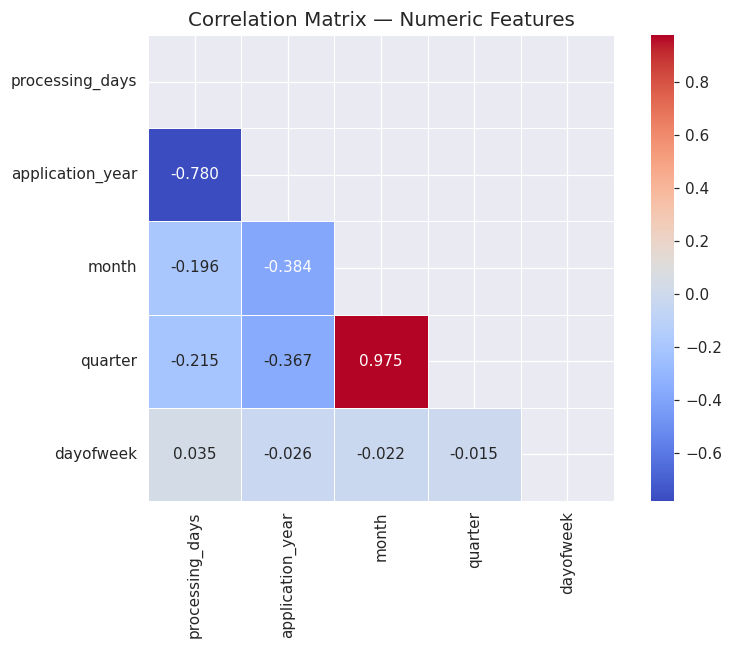

In [18]:
# ── Correlation matrix of numeric features ────────────────────────────────────
num_cols = ['processing_days', 'application_year', 'month', 'quarter', 'dayofweek']
# Keep only cols that actually exist
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

In [21]:
# ── One-hot encoding (top 20 categories for high-cardinality columns) ─────────
CAT_COLS    = ['class_of_admission', 'case_status',
               'foreign_worker_info_education']
HIGH_CARD   = ['country_of_citizenship', 'employer_state']  # limit to top 20
TOP_N       = 20
TARGET      = 'processing_days'

df_enc = df[num_cols].copy()
for col in CAT_COLS:
    if col not in df.columns: continue
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
    df_enc  = pd.concat([df_enc, dummies], axis=1)

for col in HIGH_CARD:
    if col not in df.columns: continue
    top_cats = df[col].value_counts().nlargest(TOP_N).index
    temp     = df[col].where(df[col].isin(top_cats), other='OTHER')
    dummies  = pd.get_dummies(temp, prefix=col, drop_first=False)
    df_enc   = pd.concat([df_enc, dummies], axis=1)

X = df_enc.drop(columns=[TARGET])
y = df_enc[TARGET]
X = X.astype(float)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape        : {y.shape}')

Feature matrix shape: (14622, 96)
Target shape        : (14622,)


Training Random Forest (this may take ~30 s)…


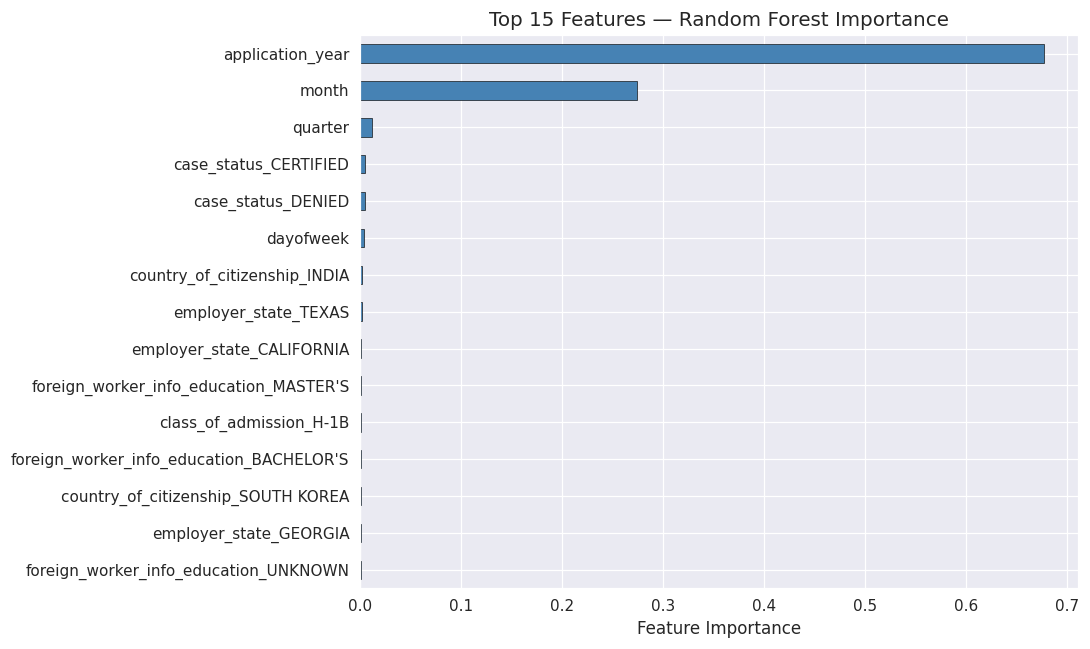

In [22]:
# ── Random Forest feature importance ──────────────────────────────────────────
print('Training Random Forest (this may take ~30 s)…')
rf = RandomForestRegressor(n_estimators=100, max_depth=12,
                           n_jobs=-1, random_state=42)
rf.fit(X, y)

importances_rf = pd.Series(rf.feature_importances_, index=X.columns)
top15_rf       = importances_rf.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15_rf.plot(kind='barh', color='steelblue', edgecolor='k', linewidth=0.4)
plt.title('Top 15 Features — Random Forest Importance')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

Computing Mutual Information scores…


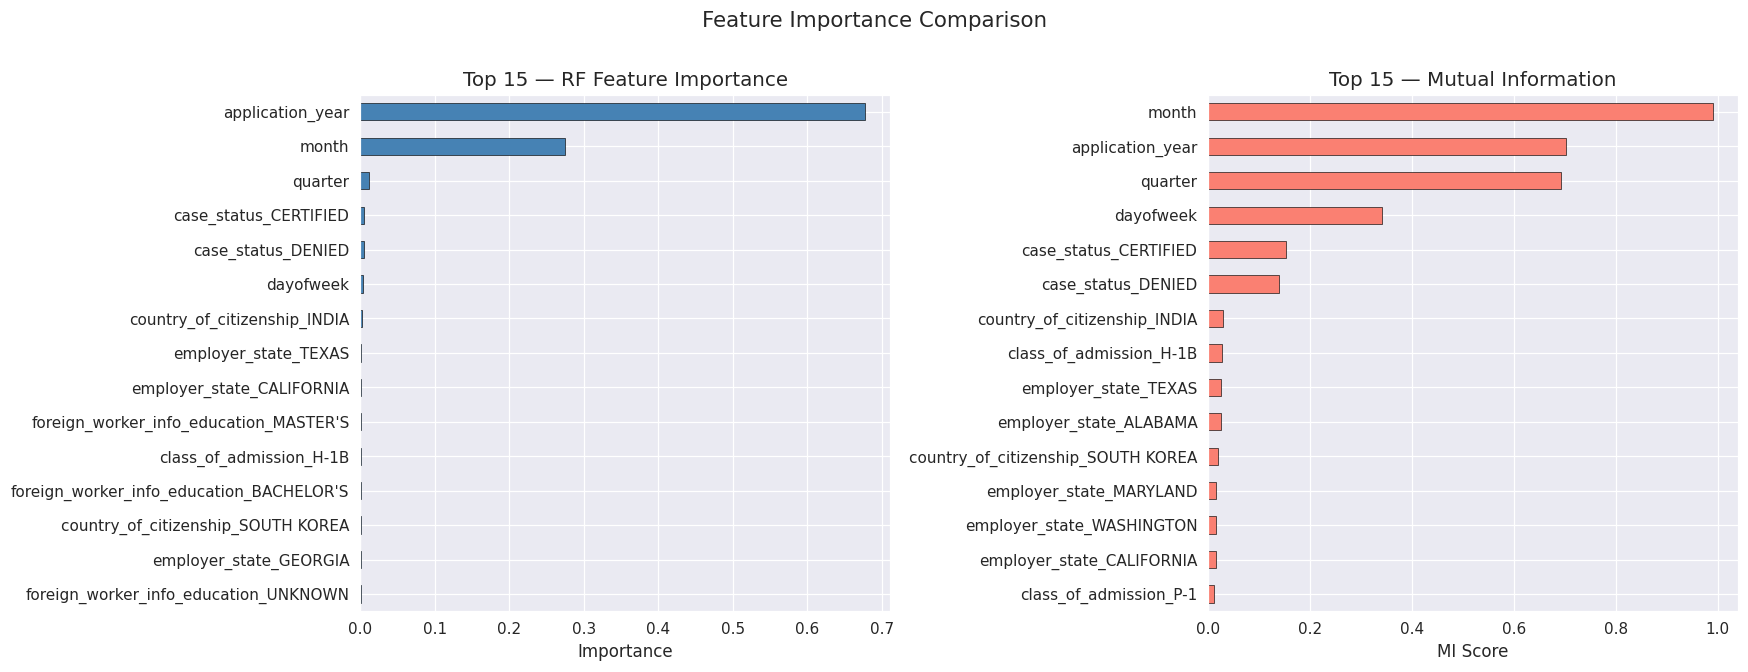

In [23]:
# ── Mutual Information scores ─────────────────────────────────────────────────
print('Computing Mutual Information scores…')
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series  = pd.Series(mi_scores, index=X.columns)
top15_mi   = mi_series.nlargest(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_rf.plot(kind='barh', ax=axes[0], color='steelblue',
              edgecolor='k', linewidth=0.4)
axes[0].set_title('Top 15 — RF Feature Importance')
axes[0].set_xlabel('Importance')

top15_mi.plot(kind='barh', ax=axes[1], color='salmon',
              edgecolor='k', linewidth=0.4)
axes[1].set_title('Top 15 — Mutual Information')
axes[1].set_xlabel('MI Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [24]:
# ── 6.1 Country-average processing time
df['country_avg_processing'] = (
    df.groupby('country_of_citizenship')['processing_days']
      .transform('mean')
)

# ── 6.2 State workload per year-month
df['state_workload'] = (
    df.groupby(['employer_state', 'application_year', 'month'])['processing_days']
      .transform('count')
)

# ── 6.3 Visa-type average processing time
df['visa_type_avg'] = (
    df.groupby('class_of_admission')['processing_days']
      .transform('mean')
)

# ── 6.4 Peak-month flag
overall_avg        = df['processing_days'].mean()
month_avg          = df.groupby('month')['processing_days'].mean()
peak_months        = month_avg[month_avg > overall_avg].index.tolist()
df['is_peak_month'] = df['month'].isin(peak_months).astype(int)

print(f'Overall avg processing days : {overall_avg:.1f}')
print(f'Peak months (avg > overall) : {peak_months}')
print('\nNew features preview:')
df[['country_avg_processing', 'state_workload',
    'visa_type_avg', 'is_peak_month']].head(8)

Overall avg processing days : 470.3
Peak months (avg > overall) : [1, 2, 3, 4, 5, 6, 7, 8, 9]

New features preview:


,country_avg_processing,state_workload,visa_type_avg,is_peak_month
0,470.958772,28,469.263606,0
1,468.054118,17,490.663067,0
2,440.304348,15,469.263606,0
3,468.054118,12,475.102484,0
4,468.054118,22,450.393070,0
5,468.054118,17,490.663067,0
6,470.958772,5,490.663067,1
7,484.443478,95,469.263606,0


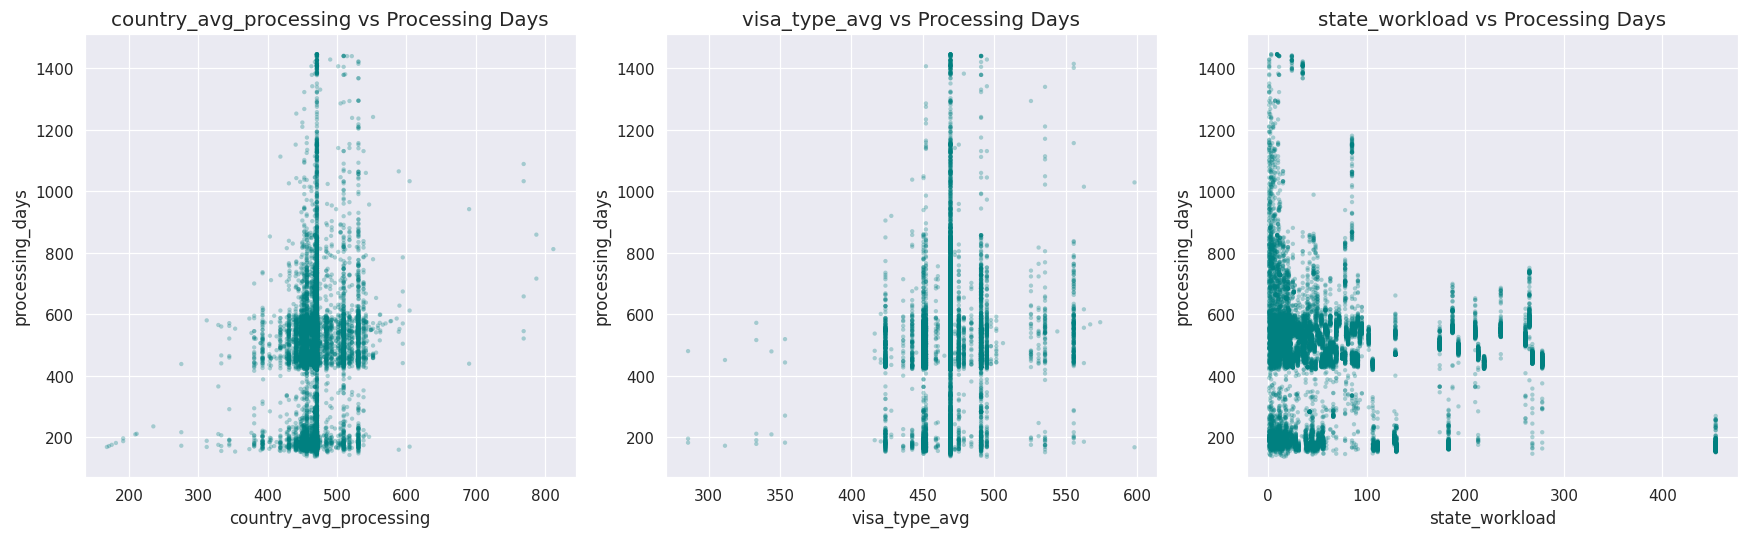

In [25]:
# ── Visualise engineered features vs target ───────────────────────────────────
eng_features = ['country_avg_processing', 'visa_type_avg', 'state_workload']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, eng_features):
    ax.scatter(df[feat], df['processing_days'],
               alpha=0.3, s=8, color='teal', edgecolors='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('processing_days')
    ax.set_title(f'{feat} vs Processing Days')
plt.tight_layout()
plt.show()

## 7. Final Output & Key Findings

In [26]:
# ── Save augmented dataset ─────────────────────────────────────────────────────
OUT_PATH = '/content/visa_data_with_features.csv'
df.to_csv(OUT_PATH, index=False)
print(f'Saved augmented dataset → {OUT_PATH}')
print(f'Final shape: {df.shape}')
df.head(3)

Saved augmented dataset → /content/visa_data_with_features.csv
Final shape: (14622, 18)


,country_of_citizenship,class_of_admission,employer_state,us_economic_sector,case_status,foreign_worker_info_education,foreign_worker_info_major,case_received_date,decision_date,processing_days,application_year,month,quarter,dayofweek,country_avg_processing,state_workload,visa_type_avg,is_peak_month
0,INDIA,H-1B,WISCONSIN,UNKNOWN,CERTIFIED,BACHELOR'S,MECHANICAL ENGINEERING,2013-11-19,2015-05-29,556,2013,11,4,1,470.958772,28,469.263606,0
1,SOUTH KOREA,UNKNOWN,MISSISSIPPI,UNKNOWN,DENIED,UNKNOWN,UNKNOWN,2013-11-12,2015-06-26,591,2013,11,4,1,468.054118,17,490.663067,0
2,GERMANY,H-1B,COLORADO,UNKNOWN,DENIED,DOCTORATE,MOLECULAR BIOLOGY,2013-11-27,2014-10-16,323,2013,11,4,2,440.304348,15,469.263606,0
